In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlran-aekam/MLRan_X_test_RFE.csv
/kaggle/input/mlran-aekam/mlran_dataset_metadata.csv
/kaggle/input/mlran-aekam/MLRan_X_train_RFE.csv
/kaggle/input/mlran-aekam/MLRan_labels.csv
/kaggle/input/mlran-aekam/type_test_sampleids.csv
/kaggle/input/mlran-aekam/type_train_sampleids.csv
/kaggle/input/mlran-aekam/RFE_selected_feature_names_dic.json


In [2]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 104.3 MB/s eta 0:00:00


Starting Advanced QNN Pipeline for MLRAN (with Attention & Pre-training)...
PennyLane version: 0.42.3
PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: Tesla T4

Loading training data from: /kaggle/input/mlran-aekam/MLRan_X_train_RFE.csv
Loading testing data from: /kaggle/input/mlran-aekam/MLRan_X_test_RFE.csv
Initial train data shape: (3905, 487)
Initial test data shape: (975, 487)
Final training dataset size after balancing: 3730 samples
Test dataset size: 975 samples

Dataset summary:
Training samples: 3730
Test samples: 975
Features: 483

Training advanced ensemble of 3 quantum models...

--- Quantum Model 1/3 ---

--- Pre-training classical layers for 20 epochs ---
Pre-train Epoch 5/20, Loss: 0.1123
Pre-train Epoch 10/20, Loss: 0.0011
Pre-train Epoch 15/20, Loss: 0.0001
Pre-train Epoch 20/20, Loss: 0.0000

--- Starting full hybrid training for 80 epochs ---
Epoch 1/80: Loss=2.0047, Val Acc=0.6273, Time=37.1s
Epoch 5/80: Loss=0.1483, Val Acc=0.9812, Time=38.1s
Epoch 10/80: Los

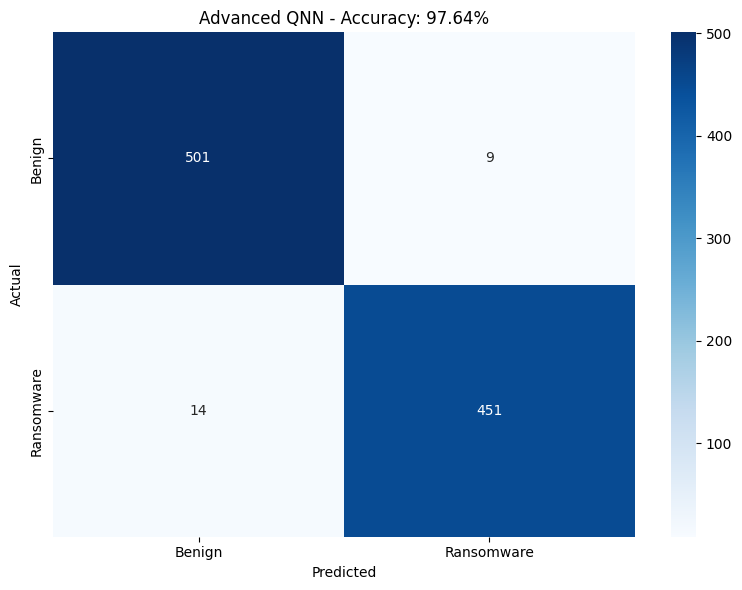


Quantum Model Configurations Used:
Model 1: Qubits=6, Layers=4, Epochs=80, LR=0.0003
Model 2: Qubits=7, Layers=4, Epochs=80, LR=0.0005
Model 3: Qubits=6, Layers=5, Epochs=80, LR=0.0003

Advanced pipeline completed successfully!


In [3]:
import numpy as np
import pandas as pd
import pennylane as qml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import warnings

warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# ============ CONFIGURATION ============
print("Starting Advanced QNN Pipeline for MLRAN (with Attention & Pre-training)...")
print(f"PennyLane version: {qml.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ============ QUANTUM CIRCUIT & LAYER ============
def create_optimized_qnn(n_qubits, n_layers):
    dev = qml.device("lightning.qubit", wires=n_qubits)
    @qml.qnode(dev, interface="torch", diff_method="adjoint")
    def optimized_circuit(inputs, weights):
        for i in range(n_qubits):
            qml.RY(inputs[i], wires=i)
        for layer in range(n_layers):
            for i in range(n_qubits):
                qml.RY(weights[layer, i, 0], wires=i)
                qml.RZ(weights[layer, i, 1], wires=i)
            for i in range(n_qubits - 1):
                qml.CNOT(wires=[i, i + 1])
            if layer % 2 == 1 and n_qubits > 2:
                qml.CNOT(wires=[n_qubits - 1, 0])
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    return optimized_circuit

class BatchQuantumLayer(nn.Module):
    def __init__(self, n_qubits, n_layers):
        super().__init__()
        self.n_qubits = n_qubits
        self.quantum_circuit = create_optimized_qnn(n_qubits, n_layers)
        weight_shape = (n_layers, n_qubits, 2)
        self.weights = nn.Parameter(torch.randn(weight_shape) * 0.1)
    def forward(self, x):
        batch_size = x.shape[0]
        outputs = []
        mini_batch_size = min(32, batch_size)
        for i in range(0, batch_size, mini_batch_size):
            batch_end = min(i + mini_batch_size, batch_size)
            batch_x = x[i:batch_end]
            batch_outputs = []
            for sample_in_batch in batch_x:
                q_out_sample = self.quantum_circuit(sample_in_batch, self.weights)
                batch_outputs.append(torch.tensor(q_out_sample, device=x.device))
            outputs.append(torch.stack(batch_outputs))
        return torch.cat(outputs)

# ============ HYBRID QNN MODEL WITH ATTENTION ============
class Attention(nn.Module):
    """A simple learnable weights layer for attention."""
    def __init__(self, feature_dim):
        super().__init__()
        self.attention_weights = nn.Parameter(torch.randn(feature_dim))
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        # x has shape (batch_size, feature_dim)
        # Apply learned weights to features
        weights = self.softmax(self.attention_weights)
        return x * weights

class OptimizedHybridQNN(nn.Module):
    def __init__(self, n_features, n_qubits, n_layers, dropout=0.5):
        super().__init__()
        self.feature_reduction = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.ReLU(),
            nn.Linear(128, n_qubits),
            nn.Tanh()
        )
        self.quantum_layer = BatchQuantumLayer(n_qubits, n_layers)
        
        # ✨ NEW: Attention layer to weigh the importance of each qubit's output
        self.attention = Attention(n_qubits)

        self.classical_layers = nn.Sequential(
            nn.Linear(n_qubits, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
    
    def forward(self, x, use_quantum=True):
        # This layer reduces high-dimensional data to the number of qubits
        x = self.feature_reduction(x)
        
        if use_quantum:
            # Pass data through the quantum circuit
            x = self.quantum_layer(x)
        # For pre-training, x (the output of feature_reduction) acts as a placeholder
        
        # Apply attention to weigh the outputs
        x_att = self.attention(x)

        # Pass the attended features to the final classical layers
        x_final = self.classical_layers(x_att)
        return x_final

# ============ DATA LOADING ============
def load_mlran_data(train_filepath, test_filepath):
    print(f"\nLoading training data from: {train_filepath}")
    train_df = pd.read_csv(train_filepath)
    print(f"Loading testing data from: {test_filepath}")
    test_df = pd.read_csv(test_filepath)
    print(f"Initial train data shape: {train_df.shape}")
    print(f"Initial test data shape: {test_df.shape}")

    try:
        cols_to_drop = ['sample_id', 'family_label', 'type_label', 'sample_type']
        y_binary_train = train_df['sample_type'].values.astype(int)
        X_train = train_df.drop(columns=cols_to_drop, errors='ignore').values.astype(np.float32)
        y_binary_test = test_df['sample_type'].values.astype(int)
        X_test = test_df.drop(columns=cols_to_drop, errors='ignore').values.astype(np.float32)
    except KeyError:
        print("Error: 'sample_type' column not found.")
        return None, None, None, None

    # Balance the training data
    class_0_idx = np.where(y_binary_train == 0)[0]
    class_1_idx = np.where(y_binary_train == 1)[0]
    min_class_size = min(len(class_0_idx), len(class_1_idx))
    balanced_idx = np.concatenate([
        np.random.choice(class_0_idx, min_class_size, replace=False),
        np.random.choice(class_1_idx, min_class_size, replace=False)
    ])
    np.random.shuffle(balanced_idx)
    X_train = X_train[balanced_idx]
    y_binary_train = y_binary_train[balanced_idx]
    
    print(f"Final training dataset size after balancing: {len(X_train)} samples")
    print(f"Test dataset size: {len(X_test)} samples")
    
    return X_train, y_binary_train, X_test, y_binary_test

# ============ ADVANCED TRAINING WITH PRE-TRAINING ============
def train_quantum_model(X_train, y_binary_train, X_val, y_binary_val,
                       n_qubits=6, n_layers=4, epochs=80, pretrain_epochs=20, batch_size=128, lr=5e-4):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    train_dataset = TensorDataset(torch.FloatTensor(X_train_scaled), torch.LongTensor(y_binary_train))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    model = OptimizedHybridQNN(
        n_features=X_train.shape[1],
        n_qubits=n_qubits,
        n_layers=n_layers
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()

    # --- ✨ NEW: Pre-training Phase ---
    print(f"\n--- Pre-training classical layers for {pretrain_epochs} epochs ---")
    # We only train the classical layers and the feature reduction head
    pretrain_optimizer = torch.optim.AdamW(
        list(model.feature_reduction.parameters()) + list(model.attention.parameters()) + list(model.classical_layers.parameters()),
        lr=0.001
    )
    for epoch in range(pretrain_epochs):
        model.train()
        for X_batch, y_binary_batch in train_loader:
            X_batch, y_binary_batch = X_batch.to(device), y_binary_batch.to(device)
            pretrain_optimizer.zero_grad()
            output = model(X_batch, use_quantum=False) # Bypass the quantum layer
            loss = criterion(output, y_binary_batch)
            loss.backward()
            pretrain_optimizer.step()
        if (epoch + 1) % 5 == 0:
            print(f"Pre-train Epoch {epoch+1}/{pretrain_epochs}, Loss: {loss.item():.4f}")

    # --- Full Hybrid Training Phase ---
    print(f"\n--- Starting full hybrid training for {epochs} epochs ---")
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr) # Now train all parameters
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.3, patience=5, verbose=True)
    
    best_acc = 0
    best_model_state = None
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        epoch_start = time.time()
        for X_batch, y_binary_batch in train_loader:
            augmentation_strength = 0.01
            noise = torch.randn_like(X_batch) * augmentation_strength
            X_batch = X_batch + noise

            X_batch, y_binary_batch = X_batch.to(device), y_binary_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch, use_quantum=True) # Use the quantum layer
            loss = criterion(output, y_binary_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
        
        model.eval()
        val_correct = 0
        with torch.no_grad():
            X_val_tensor = torch.FloatTensor(X_val_scaled).to(device)
            for i in range(0, len(X_val_tensor), batch_size):
                output = model(X_val_tensor[i:i+batch_size], use_quantum=True)
                _, predicted = torch.max(output, 1)
                val_correct += (predicted.cpu() == torch.tensor(y_binary_val[i:i+batch_size])).sum().item()

        val_acc = val_correct / len(y_binary_val)
        scheduler.step(val_acc)
        
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = model.state_dict()
        
        epoch_time = time.time() - epoch_start
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs}: Loss={train_loss/len(train_loader):.4f}, Val Acc={val_acc:.4f}, Time={epoch_time:.1f}s")
    
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    return model.cpu(), scaler, best_acc

# ============ ENSEMBLE TRAINING ============
def train_quantum_ensemble(X_train, y_binary_train, model_configs):
    models, scalers, configs = [], [], []
    n_models = len(model_configs)
    print(f"\nTraining advanced ensemble of {n_models} quantum models...")
    for i, model_config in enumerate(model_configs):
        print(f"\n--- Quantum Model {i+1}/{n_models} ---")
        val_split = int(0.8 * len(X_train))
        indices = np.random.permutation(len(X_train))
        X_tr, y_binary_tr = X_train[indices[:val_split]], y_binary_train[indices[:val_split]]
        X_val, y_binary_val = X_train[indices[val_split:]], y_binary_train[indices[val_split:]]
        model, scaler, val_acc = train_quantum_model(X_tr, y_binary_tr, X_val, y_binary_val, **model_config)
        models.append(model)
        scalers.append(scaler)
        configs.append(model_config)
        print(f"Model {i+1} validation accuracy: {val_acc:.4f}")
    return models, scalers, configs

# ============ MAIN EXECUTION ============
if __name__ == "__main__":
    TRAIN_FILE = "/kaggle/input/mlran-aekam/MLRan_X_train_RFE.csv"
    TEST_FILE = "/kaggle/input/mlran-aekam/MLRan_X_test_RFE.csv"
    
    # ✨ NEW: A focused ensemble with pre-training epochs defined
    focused_configs = [
        {'n_qubits': 6, 'n_layers': 4, 'epochs': 80, 'pretrain_epochs': 20, 'lr': 3e-4},
        {'n_qubits': 7, 'n_layers': 4, 'epochs': 80, 'pretrain_epochs': 20, 'lr': 5e-4},
        {'n_qubits': 6, 'n_layers': 5, 'epochs': 80, 'pretrain_epochs': 20, 'lr': 3e-4},
    ]

    if not os.path.exists(TRAIN_FILE) or not os.path.exists(TEST_FILE):
        print(f"Error: Data files not found.")
        exit(1)
    
    start_time = time.time()
    X_train, y_binary_train, X_test, y_binary_test = load_mlran_data(TRAIN_FILE, TEST_FILE)
    
    if X_train is not None:
        print(f"\nDataset summary:")
        print(f"Training samples: {len(X_train)}")
        print(f"Test samples: {len(X_test)}")
        print(f"Features: {X_train.shape[1]}")
        
        models, scalers, configs = train_quantum_ensemble(
            X_train, y_binary_train, model_configs=focused_configs
        )
        
        print("\n\nEvaluating advanced ensemble on test set...")
        all_predictions = []
        for i, (model, scaler) in enumerate(zip(models, scalers)):
            print(f"Running inference with model {i+1}...")
            X_test_scaled = scaler.transform(X_test)
            X_test_tensor = torch.FloatTensor(X_test_scaled)
            model.eval()
            predictions = []
            with torch.no_grad():
                batch_size = 256
                for j in range(0, len(X_test_tensor), batch_size):
                    output = model(X_test_tensor[j:j + batch_size], use_quantum=True)
                    _, preds = torch.max(output, 1)
                    predictions.extend(preds.cpu().numpy())
            all_predictions.append(predictions)
        
        all_predictions = np.array(all_predictions)
        ensemble_preds = np.apply_along_axis(lambda x: np.bincount(x).argmax(), 0, all_predictions)
        
        accuracy = accuracy_score(y_binary_test, ensemble_preds)
        f1 = f1_score(y_binary_test, ensemble_preds)
        total_time = time.time() - start_time
        
        print(f"\n{'='*60}")
        print("ADVANCED QUANTUM NEURAL NETWORK RESULTS")
        print(f"{'='*60}")
        print(f"Test Accuracy: {accuracy:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"Total Time: {total_time/60:.1f} minutes ({total_time/3600:.2f} hours)")
        
        print("\nClassification Report:")
        print(classification_report(y_binary_test, ensemble_preds,
                                  target_names=['Benign (0)', 'Ransomware (1)'],
                                  digits=4))
        
        cm = confusion_matrix(y_binary_test, ensemble_preds)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Benign', 'Ransomware'],
                    yticklabels=['Benign', 'Ransomware'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title(f'Advanced QNN - Accuracy: {accuracy:.2%}')
        plt.tight_layout()
        plt.savefig('mlran_advanced_qnn_results.png')
        plt.show()
        
        print("\nQuantum Model Configurations Used:")
        for i, config in enumerate(configs):
            print(f"Model {i+1}: Qubits={config['n_qubits']}, Layers={config['n_layers']}, Epochs={config['epochs']}, LR={config['lr']:.4f}")
        
        print(f"\nAdvanced pipeline completed successfully!")